In [1]:
import torch

In [15]:
import torch
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
import os

In [2]:
imagenet_mean=[0.485, 0.456, 0.406]
imagenet_std=[0.229, 0.224, 0.225]

In [3]:
## routine to print stats of a model
def print_model_weight_stats(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print("{}: Number of fronzen param = {:,d}, number of trainable param = {:,}".format(type(model),frozen_params, trainable_params))

## calculate the pareto value
def compute_pareto_value(acc, msize):
    ## accuracy must be between 0.0 and 0.9999
    ## model size should be in millions, between 1.0 and 900!
    if not ( 0.0 <= acc <= 0.9999):
        raise ValueError ("acc range must be between 0.0 and 0.9999")

    if not (1.0 <= msize <= 900):
        raise ValueError("model sizse must be in millions, between 1.0M and 900M")

    xdist = 0.99 - acc
    ydist = math.log10( np.float64(msize) )

    # assumption: range of accuracy is between 0.99 to 0.80 -> delta 0.2
    # range of model is from 1M to 100M -> delta 2 after taking log
    # hence scale model by 0.1
    ydist = 0.1*ydist

    z_score = math.sqrt( xdist*xdist + ydist*ydist)
    return (z_score)

## use GPU if available
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [20]:
full_run = False


In [5]:
## routine to print stats of a model
def print_model_weight_stats(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print("{}: Number of fronzen param = {:,d}, number of trainable param = {:,}".format(type(model),frozen_params, trainable_params))

    return total_params

## calculate the pareto value
def compute_pareto_value(acc, msize):
    ## accuracy must be between 0.0 and 0.9999
    ## model size should be in millions, between 1.0 and 900!
    if not ( 0.0 <= acc <= 0.9999):
        raise ValueError ("acc range must be between 0.0 and 0.9999")

    if not (1.0 <= msize <= 900):
        raise ValueError("model sizse must be in millions, between 1.0M and 900M")

    xdist = 0.99 - acc
    ydist = math.log10( np.float64(msize) )

    # assumption: range of accuracy is between 0.99 to 0.80 -> delta 0.2
    # range of model is from 1M to 100M -> delta 2 after taking log
    # hence scale model by 0.1
    ydist = 0.1*ydist

    z_score = math.sqrt( xdist*xdist + ydist*ydist)
    return (z_score)

## use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print("torch version:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)

cpu
torch version: 2.9.1+cu128
torch.version.cuda: 12.8


In [6]:
## now do some work
## example: dataset = datasets.Caltech101(root='./data', download=True, transform=transform)
'''transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for models like ResNet
    transforms.Lambda(lambda image: image.convert("RGB")), # Ensure 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean,
                         std=imagenet_std)
])

dataset = datasets.Caltech101(root="./data",download=True, transform=transform)
classes = dataset.categories'''
import random
'''
def worker_init_fn(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)'''

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For fully deterministic behavior:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    g = torch.Generator().manual_seed(seed)

    return g

seed = 42
g = seed_everything(seed)

'''transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])'''
dataset = datasets.Caltech101(root='./data', download=True)
classes = dataset.categories

100.0%


In [7]:
val_size = int(0.15 * len(dataset))
test_size = val_size
train_size = len(dataset) - val_size - test_size

In [11]:
# Split dataset
train_subset, val_subset, test_subset = random_split(dataset, [train_size, val_size, test_size], generator=g)
train_idx = train_subset.indices
val_idx = val_subset.indices
test_idx = test_subset.indices
print(f"train indices: {train_idx[:10]}, val indices: {val_idx[:10]}, test indices: {test_idx[:10]}")

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

def get_dataset(transform, idx):
    base = datasets.Caltech101(root='./data', download=False, transform=transform)
    dataset = Subset(base, idx)
    return dataset

train_dataset = get_dataset(train_transform, train_idx)
val_dataset = get_dataset(eval_transform, val_idx)
test_dataset = get_dataset(eval_transform, test_idx)
print(f"data shape: {train_dataset[0][0].shape}, val_data shape: {val_dataset[0][0].shape}, test_data shape: {test_dataset[0][0].shape}")
print(f"train dataset size: {len(train_dataset)}, val dataset size: {len(val_dataset)}, test dataset size: {len(test_dataset)}")


train indices: [8047, 3315, 6982, 6241, 7277, 4663, 7606, 6541, 5633, 4497], val indices: [5065, 718, 5590, 8446, 2040, 82, 1551, 3228, 6617, 481], test indices: [5793, 182, 2274, 4647, 1728, 3757, 5501, 5307, 7977, 931]
data shape: torch.Size([3, 224, 224]), val_data shape: torch.Size([3, 224, 224]), test_data shape: torch.Size([3, 224, 224])
train dataset size: 6075, val dataset size: 1301, test dataset size: 1301


In [12]:
train_dataset

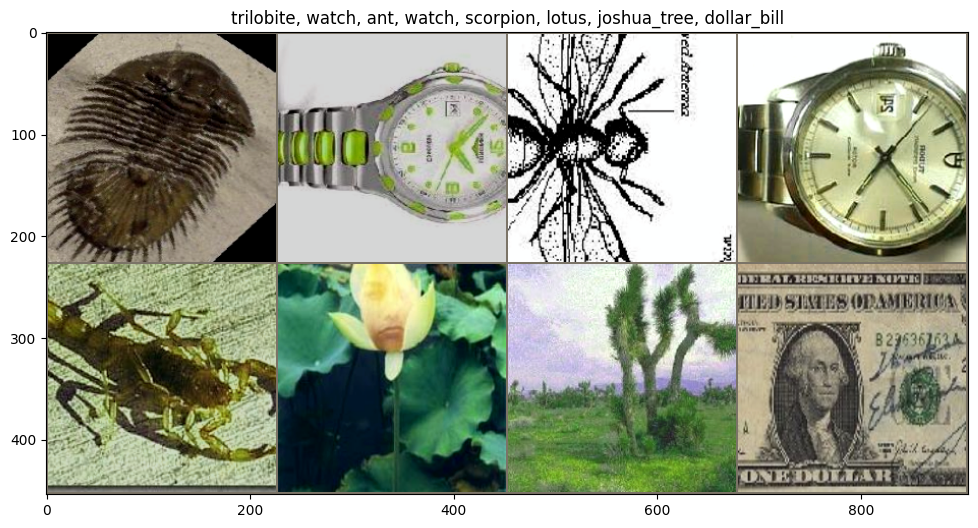

In [16]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)#, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)#, worker_init_fn=worker_init_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)#, worker_init_fn=worker_init_fn)

def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

def show_batch(loader):
    # Get a batch of training data
    inputs, classes = next(iter(loader))

    # Make a grid from batch
    out = torchvision.utils.make_grid(inputs)

    class_names = datasets.Caltech101(root='./data', download=False).categories
    inputs = inputs[:8]                          # take first 4 only
    classes = classes[:8]

    out = torchvision.utils.make_grid(inputs, nrow=4, padding=2)

    plt.figure(figsize=(12, 6))
    imshow(out, title=", ".join(class_names[int(c)] for c in classes))

show_batch(train_loader)

In [17]:
def denormalize(img_tensor):
    mean = torch.tensor(imagenet_mean, dtype=img_tensor.dtype, device=img_tensor.device).view(1, 3, 1, 1)
    std = torch.tensor(imagenet_std, dtype=img_tensor.dtype, device=img_tensor.device).view(1, 3, 1, 1)
    return img_tensor * std + mean

def show_batch(dataloader, classes):
    inputs, labels = next(iter(dataloader))
    inputs = denormalize(inputs)
    img_grid = utils.make_grid(inputs, nrow=4)
    npimg = img_grid.numpy()
    plt.figure(figsize=(20, 10))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title("Ground Truth: " + ", ".join([classes[l] for l in labels]))
    plt.show()

#show_batch(test_loader, classes)

In [18]:
## Your code
#Load Pretrained ResNet18


frozen_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in frozen_resnet18.parameters():
    param.requires_grad = False

# set up unfrozen final layer
frozen_resnet18.fc = nn.Linear(frozen_resnet18.fc.in_features, len(classes))
frozen_resnet18 = frozen_resnet18.to(device)

# Print stats after fine-tuning setup
resnet18_total_params = print_model_weight_stats(frozen_resnet18)
frozen_resnet18 = frozen_resnet18.to(device)

4.5%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/mehrdad/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


<class 'torchvision.models.resnet.ResNet'>: Number of fronzen param = 11,176,512, number of trainable param = 51,813


In [21]:
#Loss & Optimizer
# -----------------------------
wd=0
loss='ce'
def get_loss_and_opt(model, lr):
    if loss == 'ce':
        criterion = nn.CrossEntropyLoss()
    elif loss == 'smoothed_ce':
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    return criterion, optimizer
lr = 1e-2
if full_run: criterion, optimizer = get_loss_and_opt(frozen_resnet18, lr)

In [22]:
import torch.nn.functional as F

num_classes = 101  # Caltech101 has 101 categories

mixup_or_cutmix = v2.RandomChoice([
    v2.MixUp(num_classes=num_classes, alpha=0.2),
    v2.CutMix(num_classes=num_classes, alpha=1.0),
])

def ce_loss(logits, target):
    if target.dtype in (torch.long, torch.int64):  # hard labels
        return F.cross_entropy(logits, target)
    # soft labels: target shape [N, C]
    log_prob = F.log_softmax(logits, dim=1)
    return -(target * log_prob).sum(dim=1).mean()

#Training
def accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

global_step = 0
warmup_steps = 0

def warmup_lr(optimizer):
    global global_step, warmup_steps, lr
    if warmup_steps <= 0:
        return
    global_step += 1
    if global_step < warmup_steps:
        # Linear warmup
        warming_lr = lr * (global_step / warmup_steps)
        for g in optimizer.param_groups:
            g["lr"] = warming_lr

def run_epoch(loader, model, optimizer, criterion, device, train_mode = True, scheduler = None, hard_aug=None, teacher=None, T: float = 2.0, alpha: float = 0.7, tta=False):
    model.train(train_mode)
    total_loss, total_acc, n = 0.0, 0.0, 0
    # n is the number of the samples
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if train_mode:
            warmup_lr(optimizer)
            if hard_aug == 'both':
                x, label = mixup_or_cutmix(x, y)
            elif hard_aug == 'mixup':
                x, label = v2.MixUp(num_classes=num_classes, alpha=0.2)(x, y)
            elif hard_aug == 'cutmix':
                x, label = v2.CutMix(num_classes=num_classes, alpha=1.0)(x, y)
            else:
                label = y
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            ce = ce_loss(logits, label)
            if teacher is not None:
                with torch.no_grad():
                    teacher_logits = teacher(x)
                log_p = F.log_softmax(logits / T, dim=1)
                q = F.softmax(teacher_logits / T, dim=1)
                kd = F.kl_div(log_p, q, reduction="batchmean") * (T * T)
                loss = alpha * ce + (1.0 - alpha) * kd
            else:
                loss = ce
            loss.backward()
            optimizer.step()
            if isinstance(scheduler, lr_scheduler.CosineAnnealingLR):
                scheduler.step()
        else:
            with torch.no_grad():
                logits = model(x)
                if tta:
                    x_flipped = torch.flip(x, dims=[3])  # dims=[3] -> width dimension, therefore it's a horizontal flip
                    logits_flipped = model(x_flipped)
                    logits = (logits + logits_flipped) / 2.0
                loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy(logits, y) * bs
        n += bs
        

    return total_loss / n, total_acc / n

def train_model(model, train_loader, val_loader, criterion, optimizer, save_path, epochs=5, scheduler=None, hard_aug=None, min_delta=0.001, patience=9999, teacher=None, T: float = 2.0, alpha: float = 0.7):
    best_val_loss = 999999.99
    epochs_no_improve = 0
    model.to(device)

    for ep in range(1, 1 + epochs):

        train_loss, train_acc = run_epoch(train_loader, model, optimizer, criterion, device, train_mode=True, scheduler=scheduler, hard_aug=hard_aug, teacher=teacher, T=T, alpha=alpha)
        '''for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            if hard_aug:
                x, y_mixed = mixup_or_cutmix(x, y) ## changed

            optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            if hard_aug:
                loss = ce_loss(logits, y_mixed)  ## changed!
            else:
                loss = ce_loss(logits, y)

            loss.backward()
            optimizer.step()

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_acc  += accuracy(logits, y) * bs
            n += bs

        train_loss = total_loss / n
        train_acc = total_acc / n'''
        val_loss,   val_acc   = run_epoch(val_loader, model,  optimizer, criterion, device, train_mode=False)
        
        if scheduler is not None:
            if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        print(f"Epoch {ep:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc*100:.2f}% | "
            f"val loss {val_loss:.4f} acc {val_acc*100:.2f}% ")
        # Save the best model by validation loss
        if val_loss < best_val_loss:
            torch.save({"model_state": model.state_dict(),}, save_path)
            print(f"  ↳ Saved new best to {save_path}")

        if val_loss < best_val_loss - min_delta:
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"no improvement for {epochs_no_improve} epochs")
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {ep} epochs.")
            break

        if val_loss < best_val_loss:
            best_val_loss = val_loss

In [23]:
print(frozen_resnet18.fc.out_features)


101


In [24]:
save_path = "fres18_best.pt"
if full_run: train_model(frozen_resnet18, train_loader, val_loader, criterion, optimizer, save_path)

In [25]:
## testing loss

#Testing routine
def run_test_dataset(model, test_loader, tta=False):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if tta:#test time augmentation
                images_flipped = torch.flip(images, dims=[3])  # dims=[3] -> width dimension, therefore it's a horizontal flip
                outputs_flipped = model(images_flipped)
                outputs = (outputs + outputs_flipped) / 2.0
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")
    return avg_loss, accuracy / 100.0


if full_run: _, fres18_acc = run_test_dataset(frozen_resnet18, test_loader)


#Visualization pediction


def visualize_predictions(model, dataset, device, n_rows: int = 2, n_cols: int = 3):
    """
    Run inference on the first n_samples of a dataset and plot them
    with ground-truth (GT) and predicted (Pred) labels.

    Parameters
    ----------
    model : torch.nn.Module
        Trained PyTorch model.
    dataset : torch.utils.data.Dataset
        Dataset providing (image, label) pairs.
    device : torch.device
        Device to run inference on.
    n_rows : int, optional
        Number of rows, default = 2.
    n_cols : int, optional
        Number of cols, default = 3
    """
    model.eval()
    n_samples = n_rows * n_cols

    ### Your code here
    inputs, labels = [], []
    for i in range(n_samples):
        input, label = dataset[i]
        inputs.append(input)
        labels.append(label)

    with torch.no_grad():
        x_batch = torch.stack(inputs)
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        preds = logits.argmax(dim=1).cpu().numpy()

    # Denormalize and move to CPU
    x_batch_cpu = denormalize(x_batch.cpu())

    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    
    for i in range(n_samples):
        plt.subplot(n_rows, n_cols, i + 1)
        img = x_batch_cpu[i]
        img = img.permute(1,2,0).numpy()
        plt.imshow(img)
        plt.title(f"GT: {labels[i]}, Pred: {preds[i]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

if full_run: visualize_predictions(frozen_resnet18, test_dataset, device)

In [26]:

## ResNet18, transfer learning
## code
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet18.fc = nn.Linear(resnet18.fc.in_features, len(classes))
resnet18 = resnet18.to(device)
lr=1e-4
criterion, optimizer = get_loss_and_opt(resnet18, lr)
save_path = "res18_best.pt"
if full_run: train_model(resnet18, train_loader, val_loader, criterion, optimizer, save_path)

In [27]:
## testing loss
if full_run: _, resnet18_acc = run_test_dataset(resnet18, test_loader)

In [28]:
if full_run: visualize_predictions(resnet18, test_dataset, device)


In [31]:
## fine tuning shuffle Net
## repeat
frozen_shuffle_v2_x1_0 = models.shufflenet_v2_x1_0(weights='DEFAULT')
for param in frozen_shuffle_v2_x1_0.parameters():
    param.requires_grad = False
frozen_shuffle_v2_x1_0.fc = nn.Linear(frozen_shuffle_v2_x1_0.fc.in_features, len(classes))
frozen_shuffle_v2_x1_0 = frozen_shuffle_v2_x1_0.to(device)
print_model_weight_stats(frozen_shuffle_v2_x1_0)
lr=1e-3
criterion, optimizer = get_loss_and_opt(frozen_shuffle_v2_x1_0, lr)
save_path = "frozen_shuffle_v2_x1_0_best.pt"

if full_run: train_model(frozen_shuffle_v2_x1_0, train_loader, val_loader, criterion, optimizer, save_path)

55.5%

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /home/mehrdad/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100.0%


<class 'torchvision.models.shufflenetv2.ShuffleNetV2'>: Number of fronzen param = 1,253,604, number of trainable param = 103,525


In [32]:
_, f_shuffle_v2_x1_0_acc =run_test_dataset(frozen_shuffle_v2_x1_0, test_loader)


Test Loss: 4.6212, Test Accuracy: 0.23%


In [33]:
if full_run: visualize_predictions(frozen_shuffle_v2_x1_0, test_dataset, device)


In [34]:

## transfer learning of shuffleNet
##
## fine tuning shuffle Net
## repeat
shuffle_v2_x1_0 = models.shufflenet_v2_x1_0(weights='DEFAULT')
shuffle_v2_x1_0.fc = nn.Linear(shuffle_v2_x1_0.fc.in_features, len(classes))
shuffle_v2_x1_0 = shuffle_v2_x1_0.to(device)
shuffle_v2_x1_0_total_params = print_model_weight_stats(shuffle_v2_x1_0)
lr = 1e-3
criterion, optimizer = get_loss_and_opt(shuffle_v2_x1_0, lr)
save_path = "shuffle_v2_x1_0_best.pt"

if full_run: train_model(shuffle_v2_x1_0, train_loader, val_loader, criterion, optimizer, save_path)

<class 'torchvision.models.shufflenetv2.ShuffleNetV2'>: Number of fronzen param = 0, number of trainable param = 1,357,129


In [35]:
if full_run: _, shuffle_v2_x1_0_acc = run_test_dataset(shuffle_v2_x1_0, test_loader)


In [36]:
if full_run: visualize_predictions(shuffle_v2_x1_0, test_dataset, device)
